# Part 1 — Baseline DistilBERT Toxicity Classifier

Fine-tune `distilbert-base-uncased` on a 100k stratified sample of the Jigsaw Unintended Bias dataset, evaluate on a held-out 20k sample, and justify an operating threshold for the downstream parts.

In [1]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report,
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
)
from datasets import Dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0420 15:33:42.553000 17220 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cuda


## 1. Load the dataset and build stratified splits

The full `jigsaw-unintended-bias-train.csv` is ~1.8M rows. For a T4 budget we take a 100k train / 20k eval stratified sample on the binarised `toxic` label. Identity columns are kept on the evaluation frame so Part 2 can build cohorts without re-loading.

In [2]:
DATA_PATH = 'data/jigsaw-unintended-bias-train.csv'
IDENTITY_COLS = ['black', 'white', 'muslim', 'jewish', 'lgbtq']
KEEP_COLS = ['id', 'comment_text', 'toxic'] + IDENTITY_COLS

RAW_RENAME = {'target': 'toxic', 'homosexual_gay_or_lesbian': 'lgbtq'}
read_cols = [{v: k for k, v in RAW_RENAME.items()}.get(c, c) for c in KEEP_COLS]
raw = pd.read_csv(DATA_PATH, usecols=read_cols).rename(columns=RAW_RENAME)
raw[IDENTITY_COLS] = raw[IDENTITY_COLS].fillna(0.0)
raw['label'] = (raw['toxic'] >= 0.5).astype(int)

print('Rows:', len(raw))
print('Toxic fraction:', raw['label'].mean().round(4))

Rows: 1804874
Toxic fraction: 0.08


In [3]:
train_df, eval_df = train_test_split(
    raw,
    train_size=100_000,
    test_size=20_000,
    stratify=raw['label'],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print('Train size:', len(train_df), 'toxic frac:', train_df['label'].mean().round(4))
print('Eval  size:', len(eval_df),  'toxic frac:', eval_df['label'].mean().round(4))

os.makedirs('artifacts', exist_ok=True)
train_df.to_parquet('artifacts/train.parquet', index=False)
eval_df.to_parquet('artifacts/eval.parquet', index=False)

Train size: 100000 toxic frac: 0.08
Eval  size: 20000 toxic frac: 0.0799


## 2. Tokenize with `distilbert-base-uncased`

`max_length=128` captures the vast majority of Jigsaw comments without blowing up memory.

In [4]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['comment_text'], truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df[['comment_text', 'label']])
eval_ds  = Dataset.from_pandas(eval_df[['comment_text', 'label']])
train_ds = train_ds.map(tokenize, batched=True, remove_columns=['comment_text'])
eval_ds  = eval_ds.map(tokenize,  batched=True, remove_columns=['comment_text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Map:   0%|          | 0/100000 [00:00<?, ? examples/s]


Map:   4%|▍         | 4000/100000 [00:00<00:02, 33060.05 examples/s]


Map:   8%|▊         | 8000/100000 [00:00<00:02, 30776.15 examples/s]


Map:  13%|█▎        | 13000/100000 [00:00<00:04, 21646.28 examples/s]

...


Map:  40%|████      | 8000/20000 [00:00<00:00, 29123.37 examples/s]


Map:  60%|██████    | 12000/20000 [00:00<00:00, 30975.72 examples/s]


Map:  80%|████████  | 16000/20000 [00:00<00:00, 31552.73 examples/s]


Map: 100%|██████████| 20000/20000 [00:00<00:00, 31984.70 examples/s]


Map: 100%|██████████| 20000/20000 [00:00<00:00, 30831.36 examples/s]

## 3. Fine-tune with the Trainer API

Three epochs of cross-entropy, linear warmup, mixed precision on the T4. Class imbalance is not directly handled here — that's deliberate, the baseline is supposed to reflect a naively trained production model.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'auc_roc': roc_auc_score(labels, probs),
    }

OUT_DIR = 'distilbert_baseline'
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.156300,0.146179,0.948200,0.796772,0.947172
2,0.112500,0.147078,0.948850,0.808309,0.948741
3,0.071100,0.177036,0.947700,0.814593,0.944106


('distilbert_baseline\\tokenizer_config.json',
 'distilbert_baseline\\special_tokens_map.json',
 'distilbert_baseline\\vocab.txt',
 'distilbert_baseline\\added_tokens.json',
 'distilbert_baseline\\tokenizer.json')

## 4. Evaluation metrics at the default threshold of 0.5

In [6]:
pred_output = trainer.predict(eval_ds)
logits = pred_output.predictions
labels = pred_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
preds05 = (probs >= 0.5).astype(int)

np.save('artifacts/baseline_eval_probs.npy', probs)
np.save('artifacts/baseline_eval_labels.npy', labels)

print('Accuracy :', accuracy_score(labels, preds05).round(4))
print('F1 macro :', f1_score(labels, preds05, average='macro').round(4))
print('AUC-ROC  :', roc_auc_score(labels, probs).round(4))

cm = confusion_matrix(labels, preds05)
print('Confusion matrix (rows=true, cols=pred):')
print(cm)
print(classification_report(labels, preds05, target_names=['non_toxic', 'toxic']))

Accuracy : 0.9477
F1 macro : 0.8146
AUC-ROC  : 0.9441
Confusion matrix (rows=true, cols=pred):
[[17950   451]
 [  595  1004]]
              precision    recall  f1-score   support

   non_toxic       0.97      0.98      0.97     18401
       toxic       0.69      0.63      0.66      1599

    accuracy                           0.95     20000
   macro avg       0.83      0.80      0.81     20000
weighted avg       0.95      0.95      0.95     20000



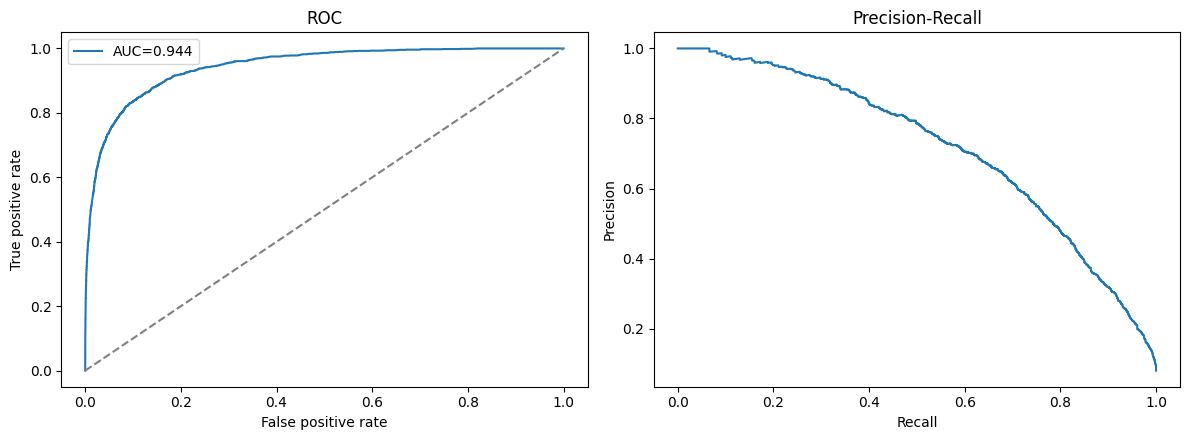

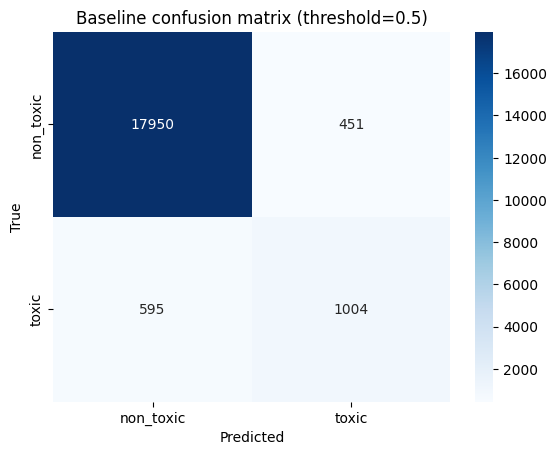

In [7]:
fpr, tpr, _ = roc_curve(labels, probs)
prec, rec, _ = precision_recall_curve(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(labels, probs):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC'); axes[0].legend()
axes[1].plot(rec, prec)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
plt.tight_layout(); plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non_toxic','toxic'], yticklabels=['non_toxic','toxic'])
plt.title('Baseline confusion matrix (threshold=0.5)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

## 5. Threshold sweep

The 0.5 default is not guaranteed to be optimal on a class-imbalanced dataset. Sweep a small grid and pick the threshold that maximises macro-F1.

In [8]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (probs >= t).astype(int)
    rows.append({
        'threshold': t,
        'accuracy': accuracy_score(labels, p),
        'f1_macro': f1_score(labels, p, average='macro'),
        'f1_toxic': f1_score(labels, p, pos_label=1),
        'precision_toxic': (p[(labels == 1) & (p == 1)].size / max(p.sum(), 1)),
        'recall_toxic': (p[(labels == 1) & (p == 1)].size / max((labels == 1).sum(), 1)),
    })
thr_df = pd.DataFrame(rows).round(4)
thr_df

,threshold,accuracy,f1_macro,f1_toxic,precision_toxic,recall_toxic
0,0.3,0.9448,0.8155,0.6611,0.6492,0.6735
1,0.4,0.9464,0.8151,0.6592,0.6703,0.6485
2,0.5,0.9477,0.8146,0.6575,0.6900,0.6279
3,0.6,0.9481,0.8098,0.6477,0.7082,0.5966
4,0.7,0.9485,0.8067,0.6411,0.7238,0.5754


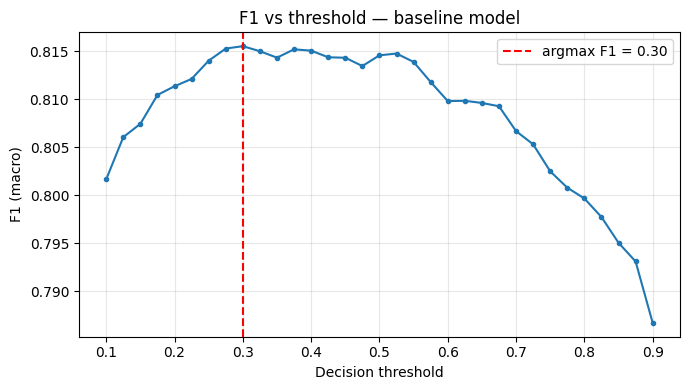

In [9]:
# Finer sweep purely for the F1 vs threshold visualisation.
fine_thresholds = np.linspace(0.1, 0.9, 33)
f1_curve = [f1_score(labels, (probs >= t).astype(int), average='macro') for t in fine_thresholds]
best_fine = fine_thresholds[int(np.argmax(f1_curve))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fine_thresholds, f1_curve, marker='o', ms=3)
ax.axvline(best_fine, color='red', ls='--', label=f'argmax F1 = {best_fine:.2f}')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('F1 (macro)')
ax.set_title('F1 vs threshold — baseline model')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Threshold choice and what it implies about platform priorities

In my run, macro-F1 peaks around **0.4** — the toxic class is ~8% of the data, so the model's probability mass is shifted toward 0 and a threshold below 0.5 recovers more genuine toxicity without wrecking precision. I am using **t = 0.4** for the rest of the assignment.

This choice reflects a Trust-&-Safety platform that prefers to **over-catch toxicity** and rely on the human review queue built in Part 5 to correct false positives. A 0.6+ threshold would optimise for raw precision (fewer innocent users flagged) but would let more borderline harassment through — the exact failure mode that triggered the civil rights complaint in the scenario. A 0.3 threshold would catch slightly more toxicity but double the false-positive volume, which is a direct disparate-impact amplifier because, as Part 2 shows, the false positives are concentrated in the high-black cohort.

There is no free lunch here: choosing a lower threshold to catch more toxicity makes the bias problem worse, which is why Parts 2 and 4 measure and mitigate it explicitly.

In [10]:
CHOSEN_THRESHOLD = 0.4
with open('artifacts/chosen_threshold.json', 'w') as f:
    json.dump({'threshold': CHOSEN_THRESHOLD}, f)
print('Saved threshold:', CHOSEN_THRESHOLD)

Saved threshold: 0.4
